# Stratégie par ticker — avec purge des lots de plus de 2 ans

On ne copie plus des élus : **on note des titres**.

Chaque fin de mois : ce que le Congrès a acheté **net** sur le dernier mois, corroboré par **au moins 2 élus**,
acheté à **poids égaux**, tenu un mois.

**La purge.** Une vente d'une ligne détenue depuis plus de 2 ans n'est pas de l'insider trading : elle ne doit
pas compter comme signal négatif. Le portefeuille des membres est reconstruit **uniquement pour dater les lots vendus**.

| constante | valeur | rôle |
|---|---|---|
| $W$ | 21 j | fenêtre du flux (1 mois) |
| $\bar a$ | 504 j | âge au-delà duquel un lot vendu ne compte plus (2 ans) |
| $b_{\min}$ | 2 | acheteurs distincts exigés |

**Simplifications assumées** : date de **transaction** (donc **borne haute**, non réplicable) · pas de coûts ·
pas de plafond de poids · univers minimal.

## §1 — Le périmètre

In [1]:
import os, warnings
from collections import deque
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 50)
plt.rcParams.update({"figure.figsize": (11, 3.6), "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 9})
BLEU, VERT, ROUGE, GRIS = "#144d90", "#146e3c", "#a01e1e", "#666666"

RACINE = "/Users/lemairealice/Downloads/Jupiter"
CLEAN  = f"{RACINE}/00_S1S2_donnees/data/clean/transactions_backtest_2014_2026.csv"
PX     = f"{RACINE}/00. S3S4 en cours/cache/prices_v2"
VOL    = f"{RACINE}/00. S3S4 en cours/cache/volume_v1"
FIGS   = f"{RACINE}/00. S3S4 en cours/figs_nb11"
os.makedirs(FIGS, exist_ok=True)

W_REF, A_BAR, B_MIN = 21, 504, 2      # les trois constantes
W = W_REF                              # fenêtre courante (sera choisie en §7.4)
print(f"W = {W} j · ā = {A_BAR} j · b_min = {B_MIN}")

W = 21 j · ā = 504 j · b_min = 2


### 1.1 Choisir le sous-ensemble

**La table est déjà propre** — c'est le produit du pipeline S1/S2 : dédoublonnage, dates réparées,
tickers résolus, montants parsés. **On ne nettoie rien ici.** On choisit un *périmètre* :

$$\text{actions} \;\wedge\; \tau_k \in [2014, 2026] \;\wedge\; \text{série de prix exploitable}$$

$x_k = (\,m_k,\; i_k,\; \tau_k,\; d_k,\; A_k\,)$ — élu, titre, date de transaction, sens, milieu de fourchette.

In [2]:
df0 = pd.read_csv(CLEAN, usecols=["bioguide_id","member_name","ticker_yahoo","direction",
                                  "transaction_date","amount_midpoint","asset_class"],
                  parse_dates=["transaction_date"])
n0 = len(df0)
n_etf = int(df0.asset_class.str.startswith("etf").sum()); n_unk = int((df0.asset_class == "unknown").sum())

a = df0[df0.asset_class == "stock"]                                             # actions seules
b = a[(a.transaction_date.dt.year >= 2014) & (a.transaction_date.dt.year <= 2026)]   # fenêtre canonique

df = (b.rename(columns={"ticker_yahoo":"tk","direction":"op",
                        "transaction_date":"tau","amount_midpoint":"A"})
        .sort_values("tau").reset_index(drop=True))

# la table clean garantit ticker et montant renseignés — on le vérifie plutôt que de faire un dropna inutile
assert df[["tk","A"]].notna().all().all(), "ticker ou montant manquant : la table clean ne devrait pas le permettre"

print(f"  table clean                    {n0:>9,}")
print(f"→ actions seules                 {len(a):>9,}   (−{n0-len(a):,} : {n_etf:,} ETF · {n_unk:,} classe inconnue)")
print(f"→ années 2014-2026               {len(b):>9,}   (−{len(a)-len(b):,} : donnée trop mince avant 2014)")
print(f"\nmembres {df.bioguide_id.nunique()} · titres {df.tk.nunique():,} · "
      f"{df.tau.min().date()} → {df.tau.max().date()}")
df.head(3)

  table clean                      134,464
→ actions seules                   128,974   (−5,490 : 2,190 ETF · 3,300 classe inconnue)
→ années 2014-2026                 128,269   (−705 : donnée trop mince avant 2014)

membres 360 · titres 3,798 · 2014-01-02 → 2026-06-30


,bioguide_id,member_name,tk,asset_class,op,A,tau
0,M001157,Michael T. McCaul,ESV,stock,sell,8000.5,2014-01-02
1,R000586,James B. Renacci,HLX,stock,buy,8000.5,2014-01-02
2,R000586,James B. Renacci,SBAC,stock,buy,8000.5,2014-01-02


### 1.2 Le calendrier de bourse $\mathcal{C}$ — celui du SPY

In [3]:
spy = pd.read_csv(f"{PX}/SPY.csv", parse_dates=["Date"]).set_index("Date")["close"].sort_index()
cal = spy.index
r_spy = spy.pct_change()
print(f"𝒞 : {len(cal):,} jours cotés · {cal[0].date()} → {cal[-1].date()}")

𝒞 : 3,645 jours cotés · 2012-01-03 → 2026-07-02


### 1.3 Charger les prix, et re-prouver leur santé

Les garde-fous sont **ceux du 05b/09**, ré-appliqués ici parce que ce notebook est autonome — ce n'est
pas un nouveau nettoyage, c'est une re-dérivation qu'on recoupe ensuite (§1.4) :

$$\#\text{obs}_i \ge 2 \;\wedge\; \min_u P_i(u) \ge 0{,}10\,\$ \;\wedge\; \max_u \left| \frac{P_i(u)}{P_i(u-1)} - 1 \right| \le 3$$

On retient aussi **le dernier jour réellement coté** — il servira à écarter les sociétés mortes.

In [4]:
PXV, LAST = {}, {}
n_abs, n_cor = 0, 0
for tk in sorted(df.tk.unique()):
    f = f"{PX}/{tk}.csv"
    if not os.path.exists(f): n_abs += 1; continue
    try:
        s = pd.read_csv(f, parse_dates=["Date"]).set_index("Date")["close"].sort_index().dropna()
    except Exception:
        n_abs += 1; continue
    if len(s) < 2 or s.min() < 0.10: n_cor += 1; continue
    v = s.pct_change().dropna()
    if len(v) and v.abs().max() > 3.0: n_cor += 1; continue
    LAST[tk] = s.index[-1]
    PXV[tk]  = s.reindex(cal).ffill().to_numpy()
print(f"titres demandés {df.tk.nunique():,} → chargés {len(PXV):,} "
      f"(absents {n_abs:,} · corrompus écartés {n_cor})")

titres demandés 3,798 → chargés 2,755 (absents 992 · corrompus écartés 51)


In [5]:
df = df[df.tk.isin(PXV)].reset_index(drop=True)
df["i0"] = cal.searchsorted(df.tau.values, side="left")     # s_k = 1er jour coté ≥ τ_k
df = df[df.i0 < len(cal)].reset_index(drop=True)
print(f"flux exploitable : {len(df):,} trades · {df.bioguide_id.nunique()} membres · {df.tk.nunique():,} titres")
print(f"  achats {(df.op=='buy').sum():,} · ventes {(df.op=='sell').sum():,}")

flux exploitable : 113,369 trades · 350 membres · 2,755 titres
  achats 57,445 · ventes 55,924


### 1.4 Recoupement — notre univers est-il cohérent avec celui du notebook 09 ?

Le 09 publie la colonne `px_couvert` : les titres dont la série de prix est exploitable, sur l'univers
**complet** (actions + ETF, toutes années). Notre univers est un **sous-ensemble** : actions seules,
2014-2026. L'inclusion doit donc être stricte.

In [6]:
t09 = pd.read_csv(f"{RACINE}/00. S3S4 en cours/tables/tickers.csv", usecols=["ticker","px_couvert"])
couv09 = set(t09.loc[t09.px_couvert, "ticker"])
manque = set(PXV) - couv09
print(f"09 · titres px_couvert (univers complet) : {len(couv09):,}")
print(f"11 · titres chargés (actions 2014-2026)  : {len(PXV):,}")
print(f"     dont absents du périmètre du 09      : {len(manque)}")
assert not manque, f"divergence à comprendre : {sorted(manque)[:10]}"
print("\n✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09")

09 · titres px_couvert (univers complet) : 3,289
11 · titres chargés (actions 2014-2026)  : 2,755
     dont absents du périmètre du 09      : 0

✅ inclusion vérifiée — notre univers est bien un sous-ensemble de celui du 09


### 1.5 Le flux dans le temps

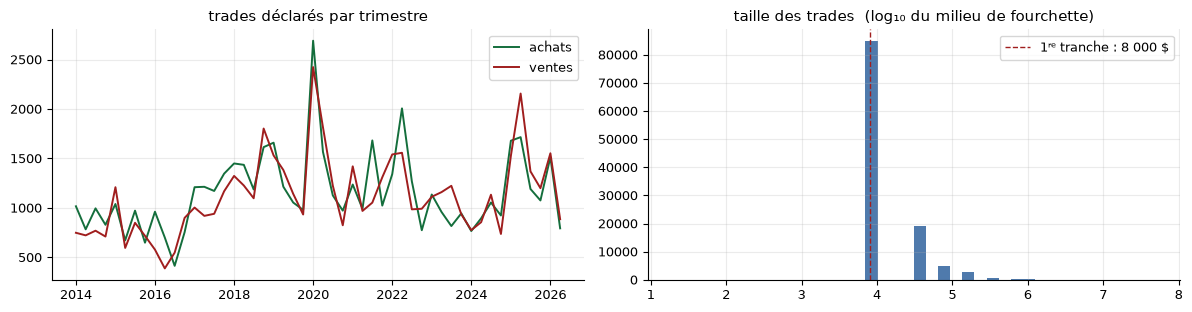

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
m = df.groupby([df.tau.dt.to_period("Q"), "op"]).size().unstack(fill_value=0)
m.index = m.index.to_timestamp()
ax[0].plot(m.index, m.get("buy", 0), color=VERT, lw=1.4, label="achats")
ax[0].plot(m.index, m.get("sell", 0), color=ROUGE, lw=1.4, label="ventes")
ax[0].set_title("trades déclarés par trimestre"); ax[0].legend()
ax[1].hist(np.log10(df.A.clip(lower=1)), bins=40, color=BLEU, alpha=.75)
ax[1].set_title("taille des trades  (log₁₀ du milieu de fourchette)")
ax[1].axvline(np.log10(8000.5), color=ROUGE, ls="--", lw=1, label="1ʳᵉ tranche : 8 000 $")
ax[1].legend(); plt.tight_layout(); plt.savefig(f"{FIGS}/flux.png", dpi=150, bbox_inches="tight"); plt.show()

## §2 — L'univers ticker $\mathcal{U}_t$

$$\mathcal{U}_t = \{\, i \;:\; \text{(a) action} \;\wedge\; \text{(b) } \exists\, u \in [\,n(t)-4,\; n(t)\,] \text{ tq } P_i(u) \text{ observée} \,\}$$

**(b) n'est pas une prudence, c'est une nécessité** : le cache prolonge les prix au dernier cours connu.
Sans ce test, une société morte en 2019 « cote » encore en 2026 — un cadavre à rendement 0 et risque 0.

In [8]:
NLAST  = {tk: cal.searchsorted(d, side="right") - 1 for tk, d in LAST.items()}   # dernier vrai cours
NFIRST = {tk: int(np.argmax(~np.isnan(PXV[tk]))) for tk in PXV}                  # premier cours disponible

def vivant(tk, i):
    # condition (b) : le titre cote DEJA (sa serie a commence) ET cote ENCORE (dernier cours <= 4 j)
    return NFIRST[tk] <= i and NLAST[tk] >= i - 4
mort = sum(1 for tk in PXV if NLAST[tk] < len(cal) - 5)
print(f"titres dont la cotation s'arrête avant la fin du calendrier : {mort:,} / {len(PXV):,} ({mort/len(PXV):.0%})")

titres dont la cotation s'arrête avant la fin du calendrier : 80 / 2,755 (3%)


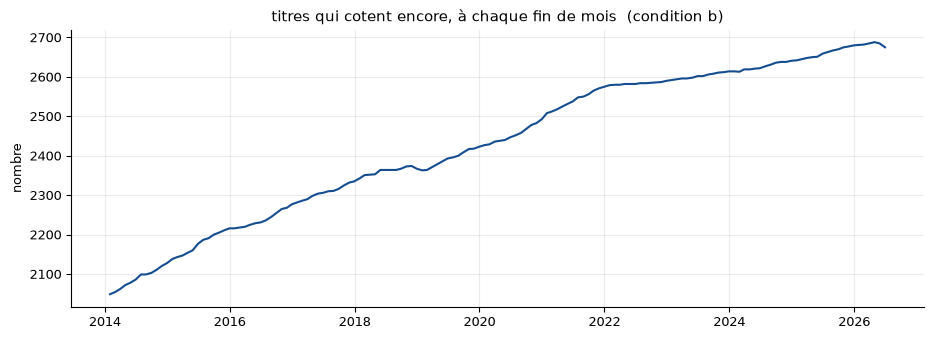

150 coupes mensuelles · 2014-01-31 → 2026-06-30


In [9]:
# les coupes commencent avec la donnée : premier mois de 2014, pas le début du calendrier de prix
DEBUT = pd.Timestamp("2014-01-31")
coupes = [cal.searchsorted(d, side="right") - 1
          for d in pd.date_range(DEBUT, cal[-1], freq="ME")]
coupes = sorted(set(i for i in coupes if W <= i < len(cal) - 1))
viv = [sum(vivant(tk, i) for tk in PXV) for i in coupes]
plt.plot([cal[i] for i in coupes], viv, color=BLEU, lw=1.5)
plt.title("titres qui cotent encore, à chaque fin de mois  (condition b)"); plt.ylabel("nombre"); plt.savefig(f"{FIGS}/univers.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"{len(coupes)} coupes mensuelles · {cal[coupes[0]].date()} → {cal[coupes[-1]].date()}")

## §3 — Le portefeuille des membres, pour dater les lots

Il **ne sert qu'à ça**. Par couple (membre, titre), file **FIFO** : un achat empile un lot
$(s_k,\, q_k)$ avec $q_k = A_k / P_{i_k}(s_k)$ ; une vente consomme les lots **les plus anciens**.

Chaque tranche $\ell$ consommée par la vente $k$ a été détenue
$$h_\ell \;=\; \#\bigl(\mathcal{C} \cap (\,s_\ell,\; s_k\,]\bigr) \quad \text{jours de bourse.}$$

In [10]:
def tranches_vendues(g):
    # pour chaque vente : la liste des (h, q) consommés, et la part non appariée
    lots, out = deque(), {}
    for idx, i0, op, A in zip(g.index.values, g.i0.values, g.op.values, g.A.values):
        p = PXV[g.tk.iat[0]][i0]
        if not np.isfinite(p) or p <= 0: continue
        q = A / p
        if op == "buy":
            lots.append([i0, q])
        else:
            reste, pieces = q, []
            while reste > 1e-12 and lots:
                s0, q0 = lots[0]
                pris = min(reste, q0); reste -= pris; lots[0][1] -= pris
                pieces.append((i0 - s0, pris))          # (h, q)
                if lots[0][1] <= 1e-12: lots.popleft()
            out[idx] = (pieces, reste)                  # reste = part non appariée
    return out

In [11]:
VENTES = {}
for (_, _), g in df.groupby(["bioguide_id","tk"], sort=False):
    VENTES.update(tranches_vendues(g))
n_v = (df.op == "sell").sum()
print(f"ventes traitées : {len(VENTES):,} / {n_v:,}")

ventes traitées : 55,061 / 55,924


### 3.1 Validation — un cas recalculé à la main, hors moteur

In [12]:
# on prend un membre×titre avec au moins 1 achat puis 1 vente
cand = (df.assign(b=(df.op=="buy").astype(int), s=(df.op=="sell").astype(int))
          .groupby(["bioguide_id","tk"])[["b","s"]].sum().query("b>=2 and s>=1"))
bid, tk = cand.index[0]
g = df[(df.bioguide_id == bid) & (df.tk == tk)]
print(f"{g.member_name.iat[0]} — {tk}")
display(g[["tau","op","A","i0"]])

# recalcul manuel
lots_m, res_m = [], {}
for idx, i0, op, A in zip(g.index, g.i0, g.op, g.A):
    q = A / PXV[tk][i0]
    if op == "buy": lots_m.append([i0, q])
    else:
        reste, pcs = q, []
        while reste > 1e-12 and lots_m:
            s0, q0 = lots_m[0]
            pris = min(reste, q0); reste -= pris; lots_m[0][1] -= pris
            pcs.append((i0 - s0, pris))
            if lots_m[0][1] <= 1e-12: lots_m.pop(0)
        res_m[idx] = (pcs, reste)
ok = all(np.allclose([x[0] for x in res_m[i][0]], [x[0] for x in VENTES[i][0]]) and
         np.allclose([x[1] for x in res_m[i][0]], [x[1] for x in VENTES[i][0]]) for i in res_m)
print(f"\n✅ recalcul manuel identique au moteur : {ok}")
for i in res_m: print(f"   vente {i} → tranches (h en jours, parts) : "
                      f"{[(int(h), round(q,2)) for h,q in res_m[i][0]]} · non apparié {res_m[i][1]:.2f}")

Richard W. Allen — ABT


,tau,op,A,i0
46306,2019-09-13,buy,32500.5,1936
46562,2019-09-27,buy,32500.5,1946
112088,2026-04-16,sell,32500.5,3591



✅ recalcul manuel identique au moteur : True
   vente 112088 → tranches (h en jours, parts) : [(1655, np.float64(340.43))] · non apparié 0.00


### 3.2 Les durées de détention observées

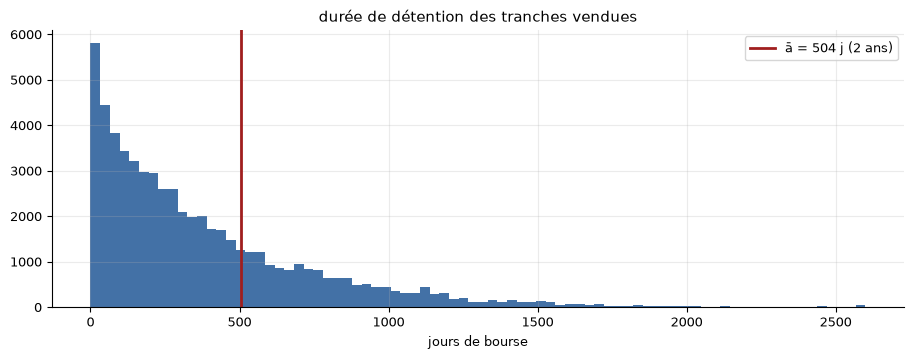

tranches vendues : 59,963 · médiane 268 j · part détenue > 2 ans : 27.3%


In [13]:
H = np.concatenate([[h for h, _ in p] for p, _ in VENTES.values() if p]) if VENTES else np.array([])
plt.hist(np.clip(H, 0, 2600), bins=80, color=BLEU, alpha=.8)
plt.axvline(A_BAR, color=ROUGE, lw=2, label=f"ā = {A_BAR} j (2 ans)")
plt.title("durée de détention des tranches vendues"); plt.xlabel("jours de bourse"); plt.legend(); plt.savefig(f"{FIGS}/durees.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"tranches vendues : {len(H):,} · médiane {np.median(H):.0f} j · "
      f"part détenue > 2 ans : {(H > A_BAR).mean():.1%}")

## §4 — La purge $\gamma$

$$\gamma_k \;=\; \frac{\sum_{\ell \subset k} \mathbf{1}\{h_\ell \le \bar a\}\, q_\ell}{\sum_{\ell \subset k} q_\ell}
\;\in\; [0,1]$$

= la part de la vente $k$ portant sur des lots détenus **moins de 2 ans**.

**achat $\Rightarrow \gamma_k = 1$** (un lot neuf n'a pas d'histoire) · **vente non appariée $\Rightarrow \gamma = 1$**
(on ne peut pas la dater, on ne l'invente pas vieille).

In [14]:
gam = np.ones(len(df))
for idx, (pieces, reste) in VENTES.items():
    tot = sum(q for _, q in pieces) + reste
    if tot <= 0: continue
    jeune = sum(q for h, q in pieces if h <= A_BAR) + reste     # le non apparié est conservé
    gam[idx] = jeune / tot
df["gamma"] = gam
v = df[df.op == "sell"]
print(f"ventes : γ = 1 (intactes) {100*(v.gamma > .999).mean():.1f}% · "
      f"γ = 0 (supprimées) {100*(v.gamma < .001).mean():.1f}% · "
      f"partielles {100*((v.gamma >= .001) & (v.gamma <= .999)).mean():.1f}%")
print(f"masse vendue conservée : {100*(v.A*v.gamma).sum()/v.A.sum():.1f}% des {v.A.sum()/1e9:.2f} Md$ déclarés")

ventes : γ = 1 (intactes) 79.9% · γ = 0 (supprimées) 17.1% · partielles 3.1%


masse vendue conservée : 89.5% des 2.11 Md$ déclarés


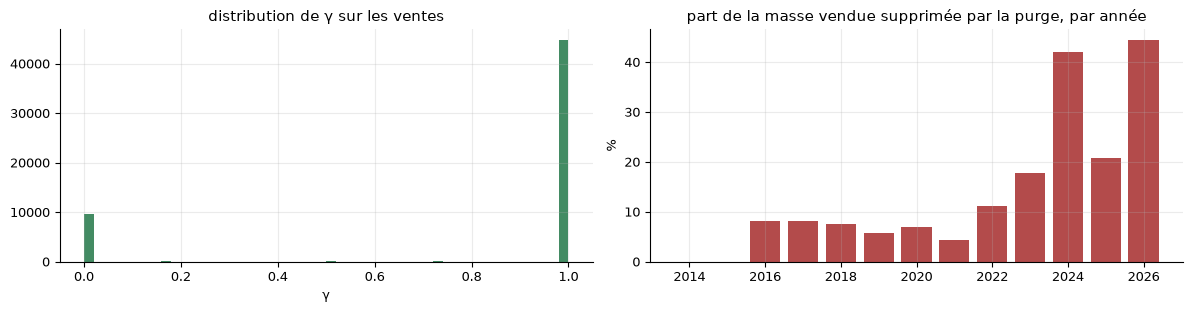

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].hist(v.gamma, bins=50, color=VERT, alpha=.8)
ax[0].set_title("distribution de γ sur les ventes"); ax[0].set_xlabel("γ")
part = v.assign(an=v.tau.dt.year).groupby("an").apply(lambda x: (x.A*x.gamma).sum()/x.A.sum())
ax[1].bar(part.index, 100*(1-part.values), color=ROUGE, alpha=.8)
ax[1].set_title("part de la masse vendue supprimée par la purge, par année"); ax[1].set_ylabel("%")
plt.tight_layout(); plt.savefig(f"{FIGS}/gamma.png", dpi=150, bbox_inches="tight"); plt.show()

## §5 — Le flux par ticker

$$\mathcal{K}_{i,t}(W) = \{\, k : i_k = i,\; t - W < s_k \le t \,\}$$
$$Buy_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k \mathbf{1}\{d_k = +1\}
\qquad
Sell^{\varphi}_{i,t} = \!\!\sum_{k \in \mathcal{K}_{i,t}}\!\! A_k\, \gamma_k\, \mathbf{1}\{d_k = -1\}$$
$$NetBuy^{\varphi}_{i,t} = \bigl[\, Buy_{i,t} - Sell^{\varphi}_{i,t} \,\bigr]^{+}
\qquad
nBuyers_{i,t} = \#\{\, m_k : k \in \mathcal{K}_{i,t},\; d_k = +1 \,\}$$

In [16]:
df["sgn"] = np.where(df.op == "buy", 1.0, -1.0)
df["Aeff"] = df.A * np.where(df.op == "buy", 1.0, df.gamma)     # A_k · γ_k pour les ventes
ordre = np.argsort(df.i0.values, kind="stable")
I0 = df.i0.values[ordre]

def flux(i1, W=None):
    W = W or W_REF
    # le panel (Buy, Sell^phi, NetBuy^phi, nBuyers) a la coupe d'indice i1
    lo, hi = np.searchsorted(I0, i1 - W, "right"), np.searchsorted(I0, i1, "right")
    g = df.iloc[ordre[lo:hi]]
    if not len(g): return pd.DataFrame(columns=["Buy","Sell","NetBuy","nBuyers"])
    buy, sell = g[g.op == "buy"], g[g.op == "sell"]
    p = pd.DataFrame({"Buy":     buy.groupby("tk").A.sum(),
                      "Sell":    sell.groupby("tk").Aeff.sum(),
                      "nBuyers": buy.groupby("tk").bioguide_id.nunique()}).fillna(0.0)
    p["NetBuy"] = (p.Buy - p.Sell).clip(lower=0)
    return p[["Buy","Sell","NetBuy","nBuyers"]]

In [17]:
i_demo = coupes[len(coupes)//2]
P_demo = flux(i_demo)
print(f"coupe du {cal[i_demo].date()} — {len(P_demo)} titres touchés sur la fenêtre de {W} j")
P_demo.sort_values("NetBuy", ascending=False).head(8).round(0)

coupe du 2020-04-30 — 604 titres touchés sur la fenêtre de 21 j


,Buy,Sell,NetBuy,nBuyers
tk,,,,
AVY,350001.0,8000.0,342000.0,1.0
TRS,207501.0,0.0,207501.0,1.0
WTM,207501.0,0.0,207501.0,1.0
G,207501.0,0.0,207501.0,1.0
CSL,207501.0,0.0,207501.0,1.0
SWK,215002.0,16001.0,199001.0,1.0
AMZN,279504.0,99002.0,180502.0,7.0
ALGN,175000.0,8000.0,167000.0,1.0


## §6 — Le signal

$$S_t = \{\, i \in \mathcal{U}_t \;:\; NetBuy^{\varphi}_{i,t} > 0 \;\wedge\; nBuyers_{i,t} \ge b_{\min} = 2 \,\}$$

In [18]:
def selection(i1, W=None):
    p = flux(i1, W)
    if not len(p): return []
    ok = (p.NetBuy > 0) & (p.nBuyers >= B_MIN)
    return [tk for tk in p.index[ok] if vivant(tk, i1)]

SEL = {i: selection(i) for i in coupes}
taille = np.array([len(SEL[i]) for i in coupes])
print(f"|S_t| : médiane {np.median(taille):.0f} · q25 {np.percentile(taille,25):.0f} · "
      f"q75 {np.percentile(taille,75):.0f} · min {taille.min()} · max {taille.max()}")
print(f"mois où |S_t| = 0 : {(taille==0).sum()} · où |S_t| < 5 : {(taille<5).sum()} / {len(taille)}")

|S_t| : médiane 28 · q25 19 · q75 44 · min 1 · max 123
mois où |S_t| = 0 : 0 · où |S_t| < 5 : 2 / 150


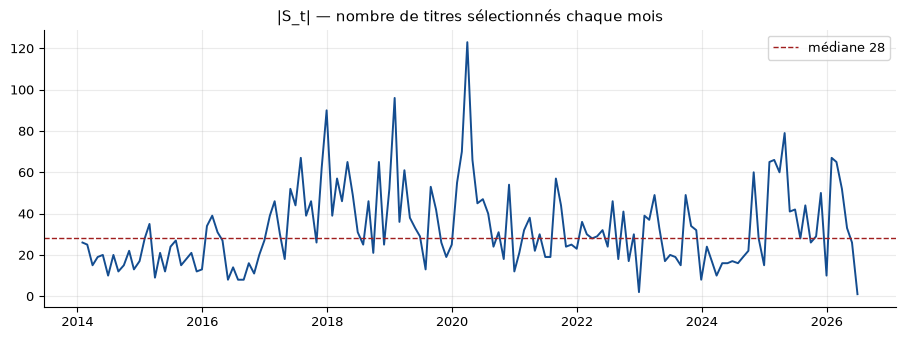

In [19]:
plt.plot([cal[i] for i in coupes], taille, color=BLEU, lw=1.4)
plt.axhline(np.median(taille), color=ROUGE, ls="--", lw=1, label=f"médiane {np.median(taille):.0f}")
plt.title("|S_t| — nombre de titres sélectionnés chaque mois"); plt.legend(); plt.savefig(f"{FIGS}/selection.png", dpi=150, bbox_inches="tight"); plt.show()

In [20]:
print(f"exemple — la sélection du {cal[i_demo].date()} ({len(SEL[i_demo])} titres) :")
P_demo.loc[SEL[i_demo]].sort_values("NetBuy", ascending=False).head(10).round(0)

exemple — la sélection du 2020-04-30 (66 titres) :


,Buy,Sell,NetBuy,nBuyers
tk,,,,
AMZN,279504.0,99002.0,180502.0,7.0
AON,115502.0,0.0,115502.0,2.0
RHI,115502.0,7733.0,107769.0,2.0
SHEL,91002.0,0.0,91002.0,3.0
RIO,91002.0,0.0,91002.0,2.0
SONY,97003.0,8000.0,89002.0,2.0
VMC,83001.0,0.0,83001.0,2.0
NFLX,123502.0,40501.0,83001.0,3.0
SBGSY,83001.0,0.0,83001.0,2.0


### 6.1 Qui a acheté quoi — la table $B_{m,t}$

Pour pondérer par membre (\S7) il faut, à chaque coupe, **qui** a acheté **quels** titres de $S_t$ :
$$\mathcal{M}_t = \{\, m : m \text{ a acheté au moins un titre de } S_t \,\}, \qquad K_t = |\mathcal{M}_t|$$
$$B_{m,t} = \{\, i \in S_t : m \text{ a acheté } i \text{ dans la fenêtre} \,\}$$

In [21]:
def acheteurs(i1, S, W=None):
    W = W or W_REF
    # rend {membre: [ses tickers de S]} sur la fenêtre de la coupe i1
    if not S: return {}
    lo, hi = np.searchsorted(I0, i1 - W, "right"), np.searchsorted(I0, i1, "right")
    g = df.iloc[ordre[lo:hi]]
    g = g[(g.op == "buy") & (g.tk.isin(set(S)))]
    return {m: sorted(set(x)) for m, x in g.groupby("bioguide_id").tk}

ACH = {i: acheteurs(i, SEL[i]) for i in coupes}
K = np.array([len(ACH[i]) for i in coupes])
print(f"K_t (membres acheteurs) : médiane {np.median(K):.0f} · q25 {np.percentile(K,25):.0f} · "
      f"q75 {np.percentile(K,75):.0f} · min {K.min()} · max {K.max()}")
nB = np.array([len(v) for i in coupes for v in ACH[i].values()])
print(f"|B_m| (titres par membre) : médiane {np.median(nB):.0f} · q90 {np.percentile(nB,90):.0f} · max {nB.max()}")

K_t (membres acheteurs) : médiane 20 · q25 15 · q75 25 · min 2 · max 45
|B_m| (titres par membre) : médiane 2 · q90 8 · max 96


In [22]:
a = ACH[i_demo]
print(f"coupe du {cal[i_demo].date()} — {len(a)} membres acheteurs, {len(SEL[i_demo])} titres retenus\n")
apercu = pd.DataFrame([{"membre": df.loc[df.bioguide_id == m, "member_name"].iat[0],
                        "|B_m|": len(v), "poids par titre": 1/(len(a)*len(v)), "ses titres": ", ".join(v[:5])}
                       for m, v in list(a.items())[:8]])
apercu.round(4)

coupe du 2020-04-30 — 27 membres acheteurs, 66 titres retenus



,membre,|B_m|,poids par titre,ses titres
0,Cindy Axne,1,0.0370,MA
1,Mo Brooks,2,0.0185,"D, DUK"
2,Susan W. Brooks,3,0.0123,"AMZN, MA, QCOM"
3,James E. Banks,1,0.0370,SBUX
4,Thomas R Carper,4,0.0093,"DGX, LHX, QCOM, SBUX"
5,K. Michael Conaway,2,0.0185,"AMZN, DUK"
6,Katherine M. Clark,2,0.0185,"LHX, MOS"
7,Gilbert Cisneros,11,0.0034,"AON, GE, HQY, LHX, LUMN"


## §7 — Le portefeuille : **une voix par membre**

Chaque membre acheteur reçoit $1/K_t$ du capital, puis **répartit sa part également** entre les titres
qu'il a achetés :
$$\boxed{\;w_{i,t} \;=\; \frac{1}{K_t} \sum_{m \in \mathcal{M}_t} \frac{\mathbf{1}\{i \in B_{m,t}\}}{|B_{m,t}|}\;}$$

**Pourquoi ce poids.** Le montant $A_k$ n'y apparaît pas : les 11 M\$ d'un élu fortuné et les 15 k\$ d'un
autre pèsent **exactement $1/K$ chacun**. Le portefeuille cesse d'être piloté par la richesse.

**Trois propriétés, aucun paramètre :**
- $\sum_i w_{i,t} = \frac{1}{K}\sum_m \sum_{i \in B_m} \frac{1}{|B_m|} = \frac{1}{K}\sum_m 1 = 1$ — normalisation automatique
- $|B_m| = 1\ \forall m \Rightarrow w_i \propto b_i$ ; $\;|B_m| = |S_t|\ \forall m \Rightarrow w_i = 1/|S_t|$ (l'équipondéré)
  $\Rightarrow$ la règle se place **seule** entre les deux régimes
- un rééquilibrage de trust sur 133 lignes donne $1/(133K)$ par ligne $\Rightarrow$ **la délégation se dilue toute seule**

**À la coupe** $t_R$, exécution au close du jour suivant, puis buy-and-hold :
$$nbr_i = \frac{V(t_R{+}1)\, w_{i,t_R}}{P_i(t_R{+}1)}, \qquad
V(t) = \sum_{i} nbr_i\, P_i(t), \qquad r(t) = \frac{V(t)}{V(t-1)} - 1$$

In [23]:
def poids(i1, W=None, sel=None, ach=None):
    # w_i = (1/K) * somme_m 1{i dans B_m} / |B_m|   — restreint aux titres priçables à l'exécution
    S = [tk for tk in (sel if sel is not None else SEL[i1]) if np.isfinite(PXV[tk][i1 + 1])]
    if not S: return {}
    Sset = set(S)
    A = ach if ach is not None else ACH[i1]
    B = {m: [tk for tk in v if tk in Sset] for m, v in A.items()}
    B = {m: v for m, v in B.items() if v}
    if not B: return {}
    Kt = len(B)
    w = {}
    for m, v in B.items():
        part = 1.0 / (Kt * len(v))
        for tk in v: w[tk] = w.get(tk, 0.0) + part
    assert abs(sum(w.values()) - 1.0) < 1e-12, f"les poids ne somment pas à 1 : {sum(w.values())}"
    return w

WPO = {i: poids(i) for i in coupes[:-1]}
mx = np.array([max(v.values()) for v in WPO.values() if v])
print(f"poids max par mois : médiane {np.median(mx):.1%} · q90 {np.percentile(mx,90):.1%} · max {mx.max():.1%}")
print(f"mois où une ligne dépasse 10 % : {(mx > .10).sum()} / {len(mx)}  ({(mx > .10).mean():.0%})")

poids max par mois : médiane 11.0% · q90 18.1% · max 50.0%
mois où une ligne dépasse 10 % : 86 / 149  (58%)


In [24]:
def run():
    V = np.full(len(cal), np.nan); nbr = {}
    e0 = coupes[0] + 1
    V[e0] = 100.0
    bornes = [(coupes[j] + 1, coupes[j+1] + 1) for j in range(len(coupes) - 1)]
    for (e, e_next) in bornes:
        w = WPO.get(e - 1, {})                                       # poids « une voix par membre »
        nbr = {tk: V[e] * wi / PXV[tk][e] for tk, wi in w.items()}
        for t in range(e + 1, min(e_next, len(cal) - 1) + 1):
            V[t] = sum(q * PXV[tk][t] for tk, q in nbr.items()) if nbr else V[t - 1]
    out = pd.Series(V, index=cal)
    span = out.loc[out.first_valid_index():out.last_valid_index()]
    assert span.notna().all(), f"trous dans la NAV : {span.isna().sum()} jours"
    return span

V = run()
r = V.pct_change().dropna()
V_ref, r_ref, mx_ref, tail_ref = V.copy(), r.copy(), mx.copy(), taille.copy()   # référence W = 21
print(f"série : {V.index[0].date()} → {V.index[-1].date()} · {len(r):,} jours · NAV finale {V.iloc[-1]:.1f}")

série : 2014-02-03 → 2026-07-01 · 3,120 jours · NAV finale 554.3


### 7.1 Vérification des deux régimes limites (propriété P2)

La formule doit redonner **$w \propto b_i$** si chaque membre n'achète qu'un titre, et **$1/|S_t|$** si
tous achètent tout. On le vérifie numériquement, sur une coupe réelle.

In [25]:
i1 = i_demo; S = [tk for tk in SEL[i1] if np.isfinite(PXV[tk][i1+1])]; Sset = set(S)
B0 = {m: [tk for tk in v if tk in Sset] for m, v in ACH[i1].items()}
B0 = {m: v for m, v in B0.items() if v}

def w_de(B):
    Kt = len(B); w = {}
    for m, v in B.items():
        for tk in v: w[tk] = w.get(tk, 0.0) + 1.0/(Kt*len(v))
    return w

# régime 1 : chaque membre n'achète qu'un titre  →  w ∝ b_i
B1 = {m: [v[0]] for m, v in B0.items()}
w1 = w_de(B1)
b1 = pd.Series({tk: sum(1 for v in B1.values() if tk in v) for tk in w1})
ok1 = np.allclose(pd.Series(w1)[b1.index].values, (b1/b1.sum()).values)

# régime 2 : tous les membres achètent tous les titres  →  w = 1/|S|
B2 = {m: S for m in B0}
w2 = w_de(B2)
ok2 = np.allclose(list(w2.values()), 1.0/len(S))

print(f"régime |B_m| = 1     →  w ∝ b_i      : {ok1}")
print(f"régime B_m = S_t     →  w = 1/|S_t|  : {ok2}   (1/{len(S)} = {1/len(S):.5f})")
assert ok1 and ok2
print("\n✅ la formule niche bien les deux régimes — sans paramètre")

régime |B_m| = 1     →  w ∝ b_i      : True
régime B_m = S_t     →  w = 1/|S_t|  : True   (1/66 = 0.01515)

✅ la formule niche bien les deux régimes — sans paramètre


### 7.2 Ce que la pondération change, concrètement

In [26]:
w_reel = WPO[i_demo]
w_eq = 1/len(w_reel)
cmp = (pd.Series(w_reel).sort_values(ascending=False).to_frame("w (une voix/membre)")
         .assign(**{"w équipondéré": w_eq}))
cmp["rapport"] = cmp.iloc[:,0] / w_eq
print(f"coupe du {cal[i_demo].date()} · {len(w_reel)} titres · équipondéré = {w_eq:.4f}")
cmp.head(8).round(4)

coupe du 2020-04-30 · 66 titres · équipondéré = 0.0152


,w (une voix/membre),w équipondéré,rapport
SBUX,0.0795,0.0152,5.2489
MA,0.0664,0.0152,4.3796
AMZN,0.0533,0.0152,3.5163
ADBE,0.0463,0.0152,3.0556
CINF,0.0407,0.0152,2.6889
TMUS,0.0404,0.0152,2.6667
VSAT,0.0394,0.0152,2.5972
PINS,0.0381,0.0152,2.5163


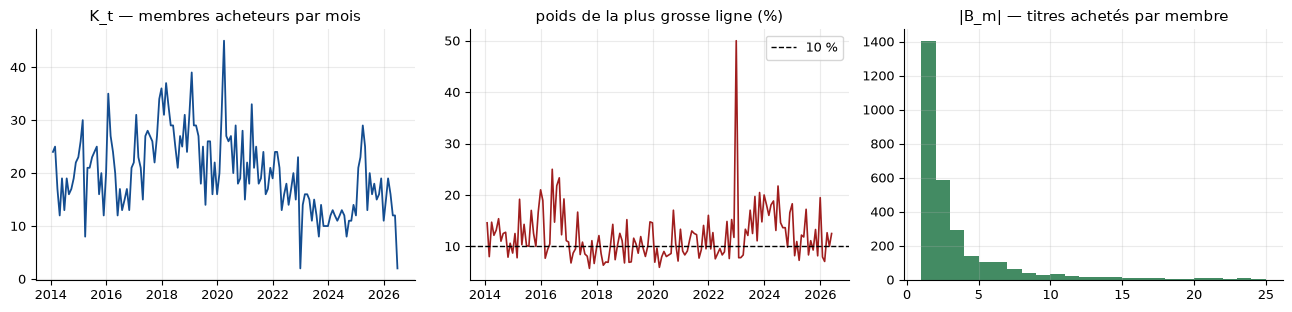

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.2))
ax[0].plot([cal[i] for i in coupes], K, color=BLEU, lw=1.3)
ax[0].set_title("K_t — membres acheteurs par mois")
ax[1].plot([cal[i] for i in coupes[:-1]], 100*mx, color=ROUGE, lw=1.2)
ax[1].axhline(10, color="k", ls="--", lw=1, label="10 %"); ax[1].legend()
ax[1].set_title("poids de la plus grosse ligne (%)")
ax[2].hist(nB, bins=range(1, 26), color=VERT, alpha=.8)
ax[2].set_title("|B_m| — titres achetés par membre")
plt.tight_layout(); plt.savefig(f"{FIGS}/poids.png", dpi=150, bbox_inches="tight"); plt.show()

### 7.3 Choisir $W$ — sur la **concentration**, jamais sur le rendement

Avec $W = 21$ j, une ligne dépasse 10 % du portefeuille dans **58 %** des mois (max 50 %) : $K_t$ est trop
petit (médiane 20, minimum 2). On desserre la seule constante qui pilote mécaniquement $K_t$ et $|S_t|$.

**Le critère est annoncé avant de calculer quoi que ce soit sur les rendements :**

$$W^\star \;=\; \min\Bigl\{\, W \in \{21, 42, 63, 126\} \;:\; \mathbb{P}\bigl[\max_i w_{i,t} > 10\,\%\bigr] \le 20\,\% \,\Bigr\}$$

Aucun rendement n'entre dans ce choix — c'est ce qui empêche le balayage de devenir une pêche au résultat.

In [28]:
lignes = []
for Wc in [21, 42, 63, 126]:
    Sc  = {i: selection(i, Wc) for i in coupes}
    Ac  = {i: acheteurs(i, Sc[i], Wc) for i in coupes}
    Wc_ = {i: poids(i, Wc, Sc[i], Ac[i]) for i in coupes[:-1]}
    mxc = np.array([max(v.values()) for v in Wc_.values() if v])
    lignes.append({"W (j)": Wc,
                   "|S_t| médian": int(np.median([len(Sc[i]) for i in coupes])),
                   "K_t médian":   int(np.median([len(Ac[i]) for i in coupes])),
                   "poids max médian": np.median(mxc),
                   "part mois > 10 %": (mxc > .10).mean()})
tabW = pd.DataFrame(lignes).set_index("W (j)")
ok = tabW[tabW["part mois > 10 %"] <= .20]
W_STAR = int(ok.index[0]) if len(ok) else int(tabW["part mois > 10 %"].idxmin())
print(tabW.assign(**{"poids max médian": (100*tabW["poids max médian"]).round(1).astype(str)+" %",
                     "part mois > 10 %": (100*tabW["part mois > 10 %"]).round(0).astype(int).astype(str)+" %"}).to_string())
print(f"\n→ W* = {W_STAR} j" + ("" if len(ok) else "  (aucun ne passe le critère : on prend le moins concentré, et on le dit)"))

       |S_t| médian  K_t médian poids max médian part mois > 10 %
W (j)                                                            
21               28          19           11.0 %             58 %
42               64          32            7.2 %             17 %
63               91          39            6.3 %              9 %
126             156          53            5.4 %              5 %

→ W* = 42 j


In [29]:
W = W_STAR                                          # on rejoue toute la chaîne avec W*
SEL = {i: selection(i, W) for i in coupes}
ACH = {i: acheteurs(i, SEL[i], W) for i in coupes}
WPO = {i: poids(i, W, SEL[i], ACH[i]) for i in coupes[:-1]}
taille = np.array([len(SEL[i]) for i in coupes]); K = np.array([len(ACH[i]) for i in coupes])
mx = np.array([max(v.values()) for v in WPO.values() if v])
V = run(); r = V.pct_change().dropna()
print(f"W = {W} j · |S_t| médian {np.median(taille):.0f} · K_t médian {np.median(K):.0f} · "
      f"poids max médian {np.median(mx):.1%} · mois > 10 % : {(mx>.10).mean():.0%}")
print(f"NAV finale {V.iloc[-1]:.1f}")

W = 42 j · |S_t| médian 64 · K_t médian 32 · poids max médian 7.2% · mois > 10 % : 17%
NAV finale 622.1


### 7.4 Validation — un mois recalculé à la main

In [30]:
j = len(coupes)//2
e, e_next = coupes[j] + 1, coupes[j+1] + 1
w = WPO[e-1]
nbr_m = {tk: V.loc[cal[e]] * wi / PXV[tk][e] for tk, wi in w.items()}
t_test = min(e + 5, e_next)
V_main = sum(q * PXV[tk][t_test] for tk, q in nbr_m.items())
print(f"segment du {cal[e].date()} · {len(w)} titres · Σw = {sum(w.values()):.10f} · "
      f"poids min {min(w.values()):.4f} / max {max(w.values()):.4f}")
print(f"V({cal[t_test].date()})  moteur {V.loc[cal[t_test]]:.4f}   à la main {V_main:.4f}   "
      f"écart {abs(V.loc[cal[t_test]] - V_main):.2e}")
assert abs(V.loc[cal[t_test]] - V_main) < 1e-8
print("✅ identique")

segment du 2020-05-01 · 146 titres · Σw = 1.0000000000 · poids min 0.0006 / max 0.0573
V(2020-05-08)  moteur 197.9369   à la main 197.9369   écart 0.00e+00
✅ identique


## §8 — Le résultat

Deux runs côte à côte : la fenêtre de référence $W = 21$ j, et $W^\star$ retenu par le critère de
concentration. **Ce sont deux essais déclarés**, pas deux chances de trouver un gagnant.

In [31]:
def bilan(Vx, nom):
    rx = Vx.pct_change().dropna()
    ax = pd.DataFrame({"s": rx.groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1)),
                       "m": r_spy.reindex(rx.index).fillna(0).groupby(rx.index.year).apply(lambda z: float((1+z).prod()-1))})
    xx = (ax.s - ax.m).values
    dd = pd.DataFrame({"p": rx, "m": r_spy.reindex(rx.index)}).join(
             pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv",
                         parse_dates=["Date"]).set_index("Date")[["RF"]]).dropna()
    yy, XX = (dd.p - dd.RF).values, (dd.m - dd.RF).values
    b, a = np.polyfit(XX, yy, 1); ee = yy - (a + b*XX)
    return {"run": nom, "excès %/an": 100*xx.mean(), "t": xx.mean()/(xx.std(ddof=1)/np.sqrt(len(xx))),
            "α %/an": 252*a*100, "t_α": a/(ee.std(ddof=2)/np.sqrt(len(yy))), "β": b,
            "NAV": Vx.iloc[-1], "ann. gagnantes": f"{int((xx>0).sum())}/{len(xx)}"}

pd.DataFrame([bilan(V_ref, f"W = {W_REF} j (référence)"), bilan(V, f"W* = {W} j")]).set_index("run").round(3)

,excès %/an,t,α %/an,t_α,β,NAV,ann. gagnantes
run,,,,,,,
W = 21 j (référence),0.303,0.165,0.059,0.029,1.038,554.284,7/13
W* = 42 j,1.706,1.030,1.048,0.645,1.023,622.132,7/13


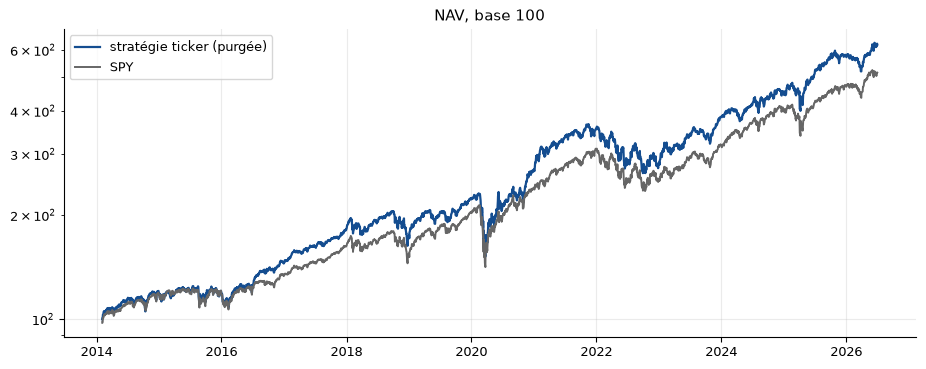

stratégie 622   ·   SPY 517


In [32]:
nav_spy = (1 + r_spy.reindex(V.index).fillna(0)).cumprod() * 100
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(V.index, V, color=BLEU, lw=1.6, label="stratégie ticker (purgée)")
ax.plot(nav_spy.index, nav_spy, color=GRIS, lw=1.4, label="SPY")
ax.set_yscale("log"); ax.set_title("NAV, base 100"); ax.legend(); plt.savefig(f"{FIGS}/nav.png", dpi=150, bbox_inches="tight"); plt.show()
print(f"stratégie {V.iloc[-1]:.0f}   ·   SPY {nav_spy.iloc[-1]:.0f}")

In [33]:
def compose(s): return float((1 + s).prod() - 1)
an = pd.DataFrame({"strat": r.groupby(r.index.year).apply(compose),
                   "spy":   r_spy.reindex(r.index).fillna(0).groupby(r.index.year).apply(compose)})
an["exces"] = an.strat - an.spy
x = an.exces.values
t_x = x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))
print(f"excès moyen {100*x.mean():+.2f} %/an · t = {t_x:+.2f} · "
      f"années gagnantes {(x>0).sum()}/{len(x)} · seuil t_{len(x)-1} ≈ 1,8")
(100*an).round(1)

excès moyen +1.71 %/an · t = +1.03 · années gagnantes 7/13 · seuil t_12 ≈ 1,8


,strat,spy,exces
Date,,,
2014,19.0,20.3,-1.3
2015,0.4,1.2,-0.9
2016,21.4,12.0,9.4
2017,24.7,21.7,3.0
2018,-3.7,-4.6,0.9
2019,27.9,31.2,-3.4
2020,21.8,18.3,3.5
2021,30.7,28.7,2.0
2022,-21.2,-18.2,-3.1


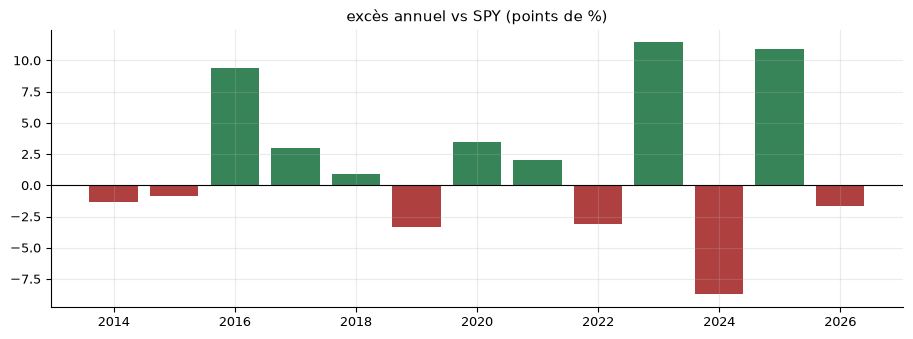

In [34]:
plt.bar(an.index, 100*an.exces, color=[VERT if v > 0 else ROUGE for v in an.exces], alpha=.85)
plt.axhline(0, color="k", lw=.8); plt.title("excès annuel vs SPY (points de %)"); plt.savefig(f"{FIGS}/exces.png", dpi=150, bbox_inches="tight"); plt.show()

In [35]:
ff = pd.read_csv(f"{RACINE}/00. S3S4 en cours/cache/ff_factors.csv", parse_dates=["Date"]).set_index("Date")
d = pd.DataFrame({"p": r, "m": r_spy.reindex(r.index)}).join(ff[["RF"]]).dropna()
y, X = (d.p - d.RF).values, (d.m - d.RF).values
beta, alpha = np.polyfit(X, y, 1)
eps = y - (alpha + beta*X); se = eps.std(ddof=2)
print(f"β = {beta:.3f}   α = {252*alpha*100:+.2f} %/an   "
      f"t_α = {alpha/(se/np.sqrt(len(y))):+.2f}   (marché en excès du taux sans risque)")

β = 1.023   α = +1.05 %/an   t_α = +0.64   (marché en excès du taux sans risque)


## §9 — Diagnostics

ADV des titres sélectionnés — médiane 102 M$/j · part sous 5 M$/j : 5.7%


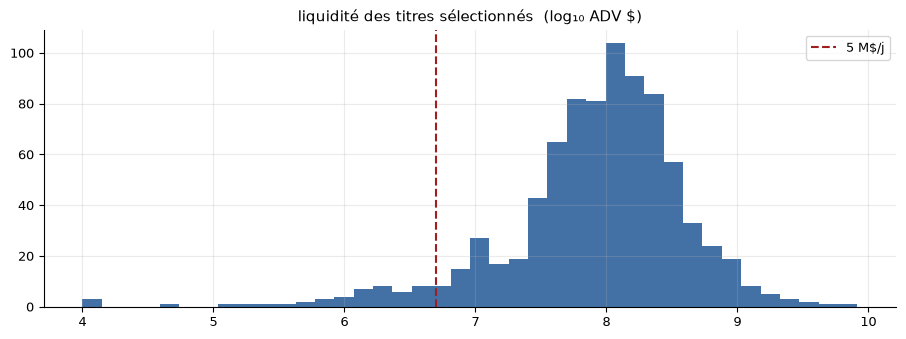

In [36]:
med_adv = {}
for tk in {t for S in SEL.values() for t in S}:
    f = f"{VOL}/{tk}.csv"
    if os.path.exists(f):
        try:
            v = pd.read_csv(f)
            med_adv[tk] = float((v.close_raw * v.volume).median())
        except Exception: pass
adv = pd.Series({tk: med_adv.get(tk, np.nan) for S in SEL.values() for tk in S}).dropna()
print(f"ADV des titres sélectionnés — médiane {adv.median()/1e6:,.0f} M$/j · "
      f"part sous 5 M$/j : {(adv < 5e6).mean():.1%}")
plt.hist(np.log10(adv.clip(lower=1e4)), bins=40, color=BLEU, alpha=.8)
plt.axvline(np.log10(5e6), color=ROUGE, ls="--", label="5 M$/j")
plt.title("liquidité des titres sélectionnés  (log₁₀ ADV $)"); plt.legend(); plt.savefig(f"{FIGS}/adv.png", dpi=150, bbox_inches="tight"); plt.show()

## §10 — Lecture

*(à remplir après lecture des chiffres ci-dessus)*

**Rappel des limites assumées** :
- la sélection utilise la **date de transaction** → l'information n'était pas publique → **borne haute**, pas une stratégie réplicable
- **aucun coût** de transaction ; le turnover mensuel n'est pas facturé
- pas de plafond de poids, pas de filtre de liquidité *(l'ADV n'est que rapportée, §9)*